In [9]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import math
import copy

In [10]:
image = cv2.imread('sar_3.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Удаление шума
image_gray = cv2.GaussianBlur(image_gray, (7, 7), 0)

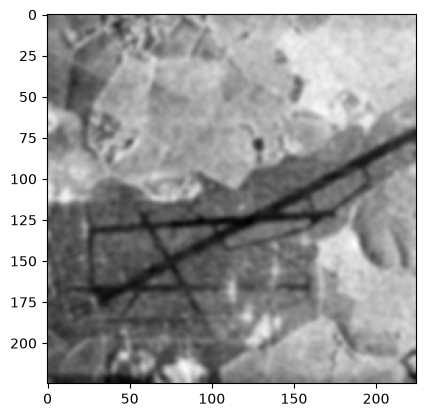

In [11]:
plt.imshow(image_gray, cmap="gray")

# 1

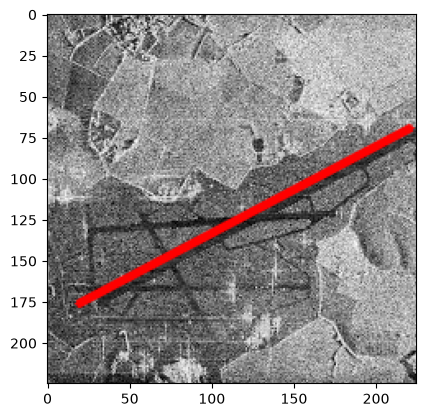

In [22]:
canny = cv2.Canny(image_gray, 50, 150, apertureSize=3)
lines = cv2.HoughLinesP(canny, 1, np.pi / 180, 70, minLineLength=20, maxLineGap=23)

image_draw = image.copy()

longest_line = None
max_length = 0

for i in range(0, len(lines)):
    x1, y1, x2, y2 = lines[i]

    length = math.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2)

    if length > max_length:
        max_length = length
        longest_line = (x1, y1, x2, y2)


x1, y1, x2, y2 = longest_line
cv2.line(image_draw, (x1, y1), (x2, y2), (0, 0, 255), 3, cv2.LINE_AA)

plt.imshow(cv2.cvtColor(image_draw, cv2.COLOR_BGR2RGB))

# 2

Лучше всего выделяет участок дороги адаптивная бинаризация или точечная при T = 70

# Отсу бинаризация

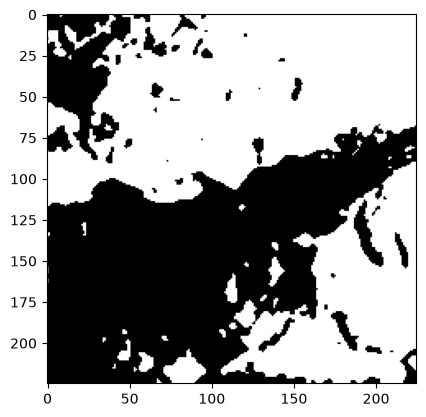

In [23]:

_,th2 = cv2.threshold(image_gray,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)
plt.imshow(th2, cmap="gray")

# Адаптивная бинаризация

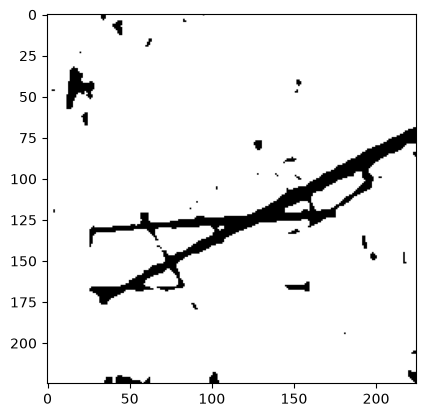

In [24]:

th3 = cv2.adaptiveThreshold(image_gray,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C,\
            cv2.THRESH_BINARY,301,41)
plt.imshow(th3, cmap="gray")

# Точечная Бинаризация

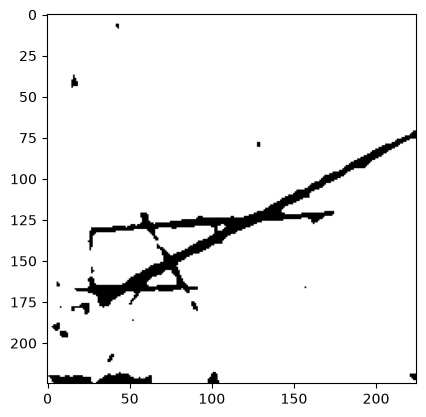

In [28]:
bin_img = copy.deepcopy(image_gray)
T  = 70
bin_img[image_gray < T] = 0
bin_img[image_gray >= T] = 255

plt.imshow(bin_img, cmap="gray")